<a href="https://colab.research.google.com/github/ibrahimelkhalilmehimda/Machine-Learning-projects/blob/main/insurance_cost_predection_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# Nouvelle section

In [ ]:
data = pd.read_csv('/content/insurance.csv')

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data.isnull().sum()


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
data.shape

(1338, 7)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_1029/2786898875.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['age'])


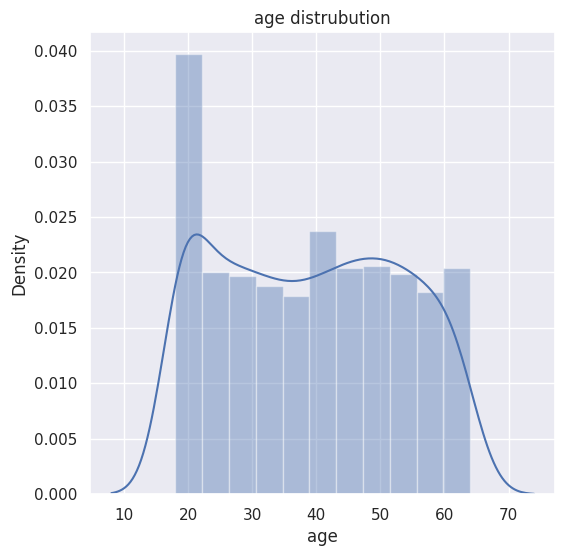

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(data['age'])
plt.title('age distrubution')
plt.show()

In [ ]:
data['sex'].value_counts()

,count
sex,
male,676
female,662


/tmp/ipykernel_1029/475553001.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['bmi'])


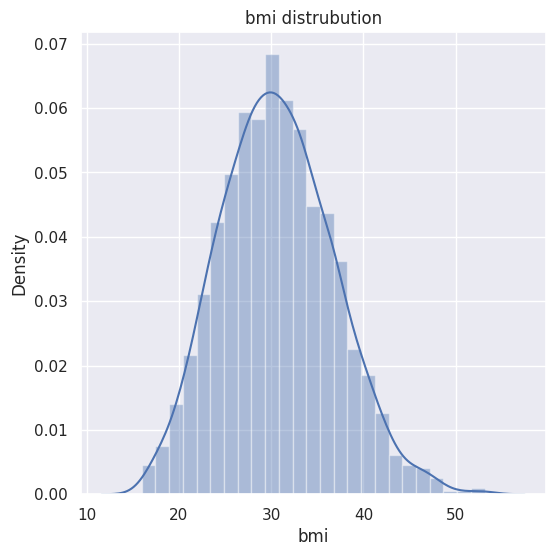

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(data['bmi'])
plt.title('bmi distrubution')
plt.show()

# encoding categorical featrues

In [ ]:
data = data.replace({'sex': {'female':0,'male':1}, 'smoker': {'yes':0,'no':1}, 'region': {'southwest':0,'northwest':1,'southeast':2,'northeast':3}})

In [ ]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,0,0,16884.92400
1,18,1,33.770,1,1,2,1725.55230
2,28,1,33.000,3,1,2,4449.46200
3,33,1,22.705,0,1,1,21984.47061
4,32,1,28.880,0,1,1,3866.85520


In [ ]:
x=data.iloc[:,0:6]
y=data.iloc[:,-1]

In [ ]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,0,0
1,18,1,33.770,1,1,2
2,28,1,33.000,3,1,2
3,33,1,22.705,0,1,1
4,32,1,28.880,0,1,1


In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.1,random_state=2)


In [ ]:
model  = LinearRegression()
model.fit(X_train, Y_train)


LinearRegression()

#evalute the models

In [ ]:
x_train_predection = model.predict(X_train)
accuracy_score_training = r2_score(x_train_predection,Y_train)

print("the accuracy score of training data is:" , accuracy_score_training )

y_test_predection = model.predict(X_test)
accuracy_score_test = r2_score(y_test_predection,Y_test)

print("the accuracy score of testing data is:" , accuracy_score_test )

the accuracy score of training data is: 0.6726432956696682
the accuracy score of testing data is: 0.6107164616419962


#predection system

In [ ]:
input_data= (18,	1,	33.770,	1,	1	,2)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
predection = model.predict(input_data_reshaped)
print("charges are :", predection[0] )


charges are : 4096.828506451684


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
